# 04 — RNN / LSTM / GRU / Seq2Seq Forecasting
Train and compare all deep learning models on ETTh1 (horizon=24).

Pipeline: Load → Clean → Feature Engineering → Split → Scale → Sliding Windows → Train All Models → Compare

In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

from gridpulse.data.download_ett import download_ett
from gridpulse.preprocessing.cleaning import clean_ett
from gridpulse.features.feature_builder import build_features
from gridpulse.data.split_time_series import split_by_time
from gridpulse.preprocessing.scaling import ScalerWrapper
from gridpulse.preprocessing.windowing import create_windows, TimeSeriesDataset

from gridpulse.models.rnn import RNNForecaster
from gridpulse.models.lstm import LSTMForecaster
from gridpulse.models.gru import GRUForecaster
from gridpulse.models.seq2seq import Seq2SeqForecaster
from gridpulse.training.trainer import TimeSeriesTrainer
from gridpulse.evaluation.metrics_forecasting import compute_all_metrics
from gridpulse.utils.paths import RAW_DIR

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
INPUT_LEN        = 96
FORECAST_HORIZON = 24
STRIDE           = 1
BATCH_SIZE       = 64
TARGET_COL       = "OT"
DATE_COL         = "date"

## 1. Data Pipeline

In [3]:
download_ett()

ett_path = RAW_DIR / "ett" / "ETTh1.csv"
df_raw = pd.read_csv(ett_path)
df = clean_ett(df_raw)

df_feat = build_features(df, target_col=TARGET_COL, date_col=DATE_COL)
print(f"After feature engineering: {df_feat.shape}")
print(f"Features: {len(df_feat.columns) - 1} (excl. date)")

2026-07-07 14:39:10.327 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTh1.csv
2026-07-07 14:39:10.340 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTh2.csv
2026-07-07 14:39:10.346 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTm1.csv
2026-07-07 14:39:10.364 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTm2.csv
2026-07-07 14:39:10.511 | INFO     | gridpulse.features.feature_builder:build_features:39 - Dropped 168 rows with NaN from feature creations.


After feature engineering: (17252, 31)
Features: 30 (excl. date)


In [4]:
train_df, val_df, test_df = split_by_time(
    df_feat, date_col=DATE_COL, train_ratio=0.6, val_ratio=0.2
)

print(f"Train : {len(train_df):>6} rows")
print(f"Val   : {len(val_df):>6} rows")
print(f"Test  : {len(test_df):>6} rows")

2026-07-07 14:39:10.553 | INFO     | gridpulse.data.split_time_series:split_by_time:28 - Split by time: train=10351, val=3450, test=3451


Train :  10351 rows
Val   :   3450 rows
Test  :   3451 rows


In [5]:
other_cols  = [c for c in df_feat.columns if c not in (DATE_COL, TARGET_COL)]
feature_cols = other_cols + [TARGET_COL]

target_col_idx = -1
NUM_FEATURES = len(feature_cols)
print(f"Total features: {NUM_FEATURES}, target '{TARGET_COL}' at index {target_col_idx}")

wrapper = ScalerWrapper(scaler=StandardScaler(), columns=feature_cols)

train_scaled = wrapper.fit_transform(train_df)
val_scaled   = wrapper.transform(val_df)
test_scaled  = wrapper.transform(test_df)

Total features: 30, target 'OT' at index -1


In [6]:
train_arr = train_scaled[feature_cols].values
val_arr   = val_scaled[feature_cols].values
test_arr  = test_scaled[feature_cols].values

X_train, y_train = create_windows(train_arr, INPUT_LEN, FORECAST_HORIZON, stride=STRIDE, target_col_idx=target_col_idx)
X_val,   y_val   = create_windows(val_arr,   INPUT_LEN, FORECAST_HORIZON, stride=STRIDE, target_col_idx=target_col_idx)
X_test,  y_test  = create_windows(test_arr,  INPUT_LEN, FORECAST_HORIZON, stride=STRIDE, target_col_idx=target_col_idx)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")

X_train: (10232, 96, 30), y_train: (10232, 24)
X_val  : (3331, 96, 30),   y_val  : (3331, 24)
X_test : (3332, 96, 30),  y_test : (3332, 24)


In [7]:
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val, y_val)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 160, Val batches: 53, Test batches: 53


## 2. Define Models & Training Config

In [8]:
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
DROPOUT     = 0.3

models_to_train = [
    RNNForecaster(NUM_FEATURES, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, forecast_horizon=FORECAST_HORIZON),
    LSTMForecaster(NUM_FEATURES, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, forecast_horizon=FORECAST_HORIZON),
    GRUForecaster(NUM_FEATURES, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, forecast_horizon=FORECAST_HORIZON),
    Seq2SeqForecaster(NUM_FEATURES, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, forecast_horizon=FORECAST_HORIZON),
]

config = {
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "max_epochs": 100,
    "patience": 15,
    "grad_clip": 1.0,
    "batch_size": BATCH_SIZE,
    "input_len": INPUT_LEN,
    "forecast_horizon": FORECAST_HORIZON,
}

for m in models_to_train:
    print(f"{m.name:30s} | params: {m.count_parameters():>10,}")

VanillaRNN_h64_L2              | params:     16,024
LSTM_h64_L2                    | params:     59,416
GRU_h64_L2                     | params:     44,952
Seq2Seq_h64_L2                 | params:    108,353


## 3. Train All Models

In [9]:
results = {}
histories = {}

for model in models_to_train:
    print(f"\n{'='*60}")
    print(f"Training: {model.name}")
    print(f"Parameters: {model.count_parameters():,}")
    print(f"{'='*60}")

    trainer = TimeSeriesTrainer(model, config)
    history = trainer.fit(train_loader, val_loader, experiment_name="dl-models-h24")
    histories[model.name] = history

    y_pred = trainer.predict(test_loader)
    metrics = compute_all_metrics(y_test, y_pred)
    results[model.name] = metrics

    print(f"Test metrics: {metrics}")

2026-07-07 14:39:11.062 | INFO     | gridpulse.training.trainer:__init__:46 - Using device: cpu
2026-07-07 14:39:11.064 | INFO     | gridpulse.training.trainer:__init__:47 - Model: VanillaRNN_h64_L2, Parameters: 16024



Training: VanillaRNN_h64_L2
Parameters: 16,024


2026-07-07 14:39:46.811 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 1/100 | Train Loss: 0.207867 | Val Loss: 0.056531 | LR: 1.00e-03
2026-07-07 14:39:46.827 | INFO     | gridpulse.training.callbacks:__call__:46 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\VanillaRNN_h64_L2_best.pt (val_loss=0.056531)
2026-07-07 14:40:32.624 | INFO     | gridpulse.training.callbacks:__call__:46 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\VanillaRNN_h64_L2_best.pt (val_loss=0.056500)
2026-07-07 14:41:21.144 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 5/100 | Train Loss: 0.103268 | Val Loss: 0.046078 | LR: 1.00e-03
2026-07-07 14:41:21.148 | INFO     | gridpulse.training.callbacks:__call__:46 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\VanillaRNN_h64_L2_best.pt (val_loss=0.046078)
2026-07-07 14:43:26.951 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 10/100 | Train Los

Test metrics: {'mae': np.float64(0.1622), 'rmse': np.float64(0.2249), 'smape': np.float64(17.81)}

Training: LSTM_h64_L2
Parameters: 59,416


2026-07-07 14:48:01.938 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 1/100 | Train Loss: 0.241944 | Val Loss: 0.197746 | LR: 1.00e-03
2026-07-07 14:48:01.943 | INFO     | gridpulse.training.callbacks:__call__:46 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\LSTM_h64_L2_best.pt (val_loss=0.197746)
2026-07-07 14:48:24.719 | INFO     | gridpulse.training.callbacks:__call__:46 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\LSTM_h64_L2_best.pt (val_loss=0.153212)
2026-07-07 14:49:31.860 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 5/100 | Train Loss: 0.073979 | Val Loss: 0.300012 | LR: 1.00e-03
2026-07-07 14:51:23.592 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 10/100 | Train Loss: 0.049041 | Val Loss: 0.494680 | LR: 5.00e-04
2026-07-07 14:53:12.364 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 15/100 | Train Loss: 0.041227 | Val Loss: 0.472388 | LR: 2.50e-04
2026-07-07 14:53:57.31

Test metrics: {'mae': np.float64(0.3156), 'rmse': np.float64(0.3893), 'smape': np.float64(40.88)}

Training: GRU_h64_L2
Parameters: 44,952


2026-07-07 14:54:42.722 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 1/100 | Train Loss: 0.222556 | Val Loss: 0.112891 | LR: 1.00e-03
2026-07-07 14:54:42.725 | INFO     | gridpulse.training.callbacks:__call__:46 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\GRU_h64_L2_best.pt (val_loss=0.112891)
2026-07-07 14:55:19.564 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 5/100 | Train Loss: 0.092017 | Val Loss: 0.163949 | LR: 1.00e-03
2026-07-07 14:58:26.910 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 10/100 | Train Loss: 0.071273 | Val Loss: 0.288020 | LR: 5.00e-04
2026-07-07 15:02:04.794 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 15/100 | Train Loss: 0.059112 | Val Loss: 0.486954 | LR: 2.50e-04
2026-07-07 15:02:48.973 | INFO     | gridpulse.training.callbacks:__call__:24 - Early stopping triggered after 15 epochs without improvement. Best val_loss: 0.112891
2026-07-07 15:02:49.020 | INFO     | gridpulse.training

Test metrics: {'mae': np.float64(0.247), 'rmse': np.float64(0.3104), 'smape': np.float64(27.83)}

Training: Seq2Seq_h64_L2
Parameters: 108,353


2026-07-07 15:03:40.499 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 1/100 | Train Loss: 0.230550 | Val Loss: 0.101729 | LR: 1.00e-03
2026-07-07 15:03:40.506 | INFO     | gridpulse.training.callbacks:__call__:46 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\Seq2Seq_h64_L2_best.pt (val_loss=0.101729)
2026-07-07 15:06:42.898 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 5/100 | Train Loss: 0.067640 | Val Loss: 0.287663 | LR: 1.00e-03
2026-07-07 15:10:39.050 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 10/100 | Train Loss: 0.042711 | Val Loss: 0.448723 | LR: 5.00e-04
2026-07-07 15:14:32.961 | INFO     | gridpulse.training.trainer:fit:161 - Epoch 15/100 | Train Loss: 0.034187 | Val Loss: 0.459397 | LR: 2.50e-04
2026-07-07 15:15:20.562 | INFO     | gridpulse.training.callbacks:__call__:24 - Early stopping triggered after 15 epochs without improvement. Best val_loss: 0.101729
2026-07-07 15:15:20.606 | INFO     | gridpulse.trai

Test metrics: {'mae': np.float64(0.2705), 'rmse': np.float64(0.333), 'smape': np.float64(31.75)}


## 4. Results Comparison

In [10]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("mae")
print(results_df.to_markdown())
results_df

|                   |    mae |   rmse |   smape |
|:------------------|-------:|-------:|--------:|
| VanillaRNN_h64_L2 | 0.1622 | 0.2249 |   17.81 |
| GRU_h64_L2        | 0.247  | 0.3104 |   27.83 |
| Seq2Seq_h64_L2    | 0.2705 | 0.333  |   31.75 |
| LSTM_h64_L2       | 0.3156 | 0.3893 |   40.88 |


,mae,rmse,smape
VanillaRNN_h64_L2,0.1622,0.2249,17.81
GRU_h64_L2,0.2470,0.3104,27.83
Seq2Seq_h64_L2,0.2705,0.3330,31.75
LSTM_h64_L2,0.3156,0.3893,40.88


## 5. Training Curves

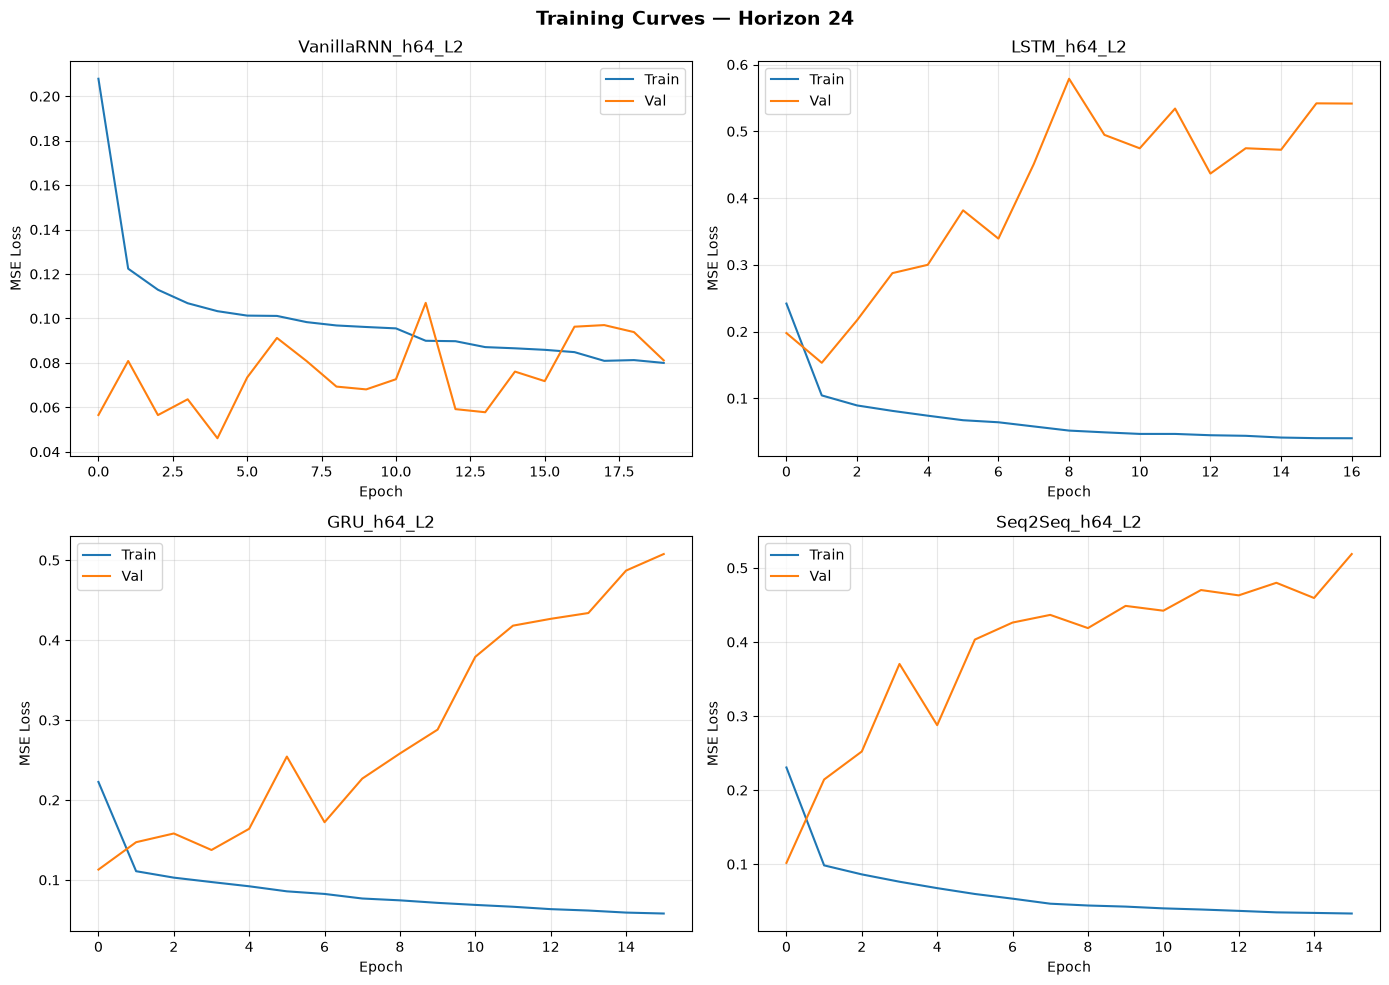

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, history) in zip(axes.flat, histories.items()):
    ax.plot(history["train_loss"], label="Train")
    ax.plot(history["val_loss"], label="Val")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Training Curves — Horizon {FORECAST_HORIZON}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

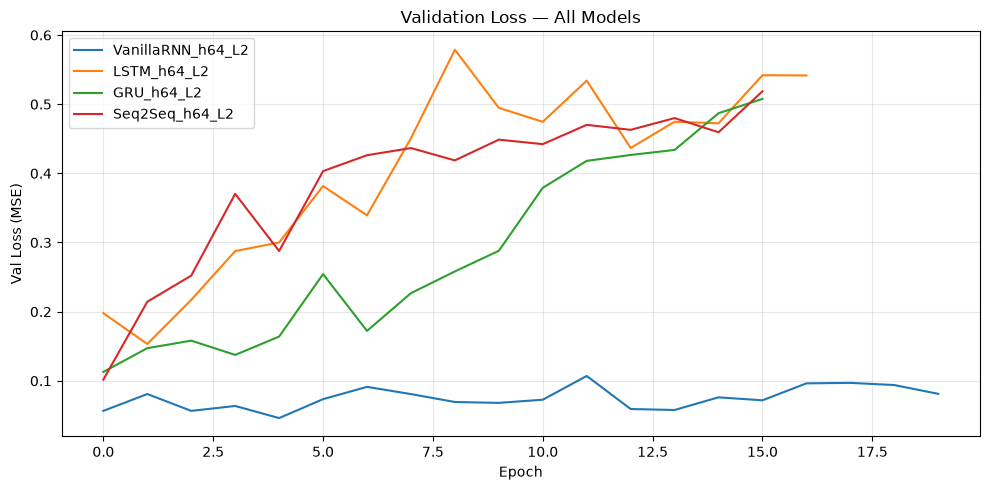

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, history in histories.items():
    ax.plot(history["val_loss"], label=name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss (MSE)")
ax.set_title("Validation Loss — All Models")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Metrics Bar Chart

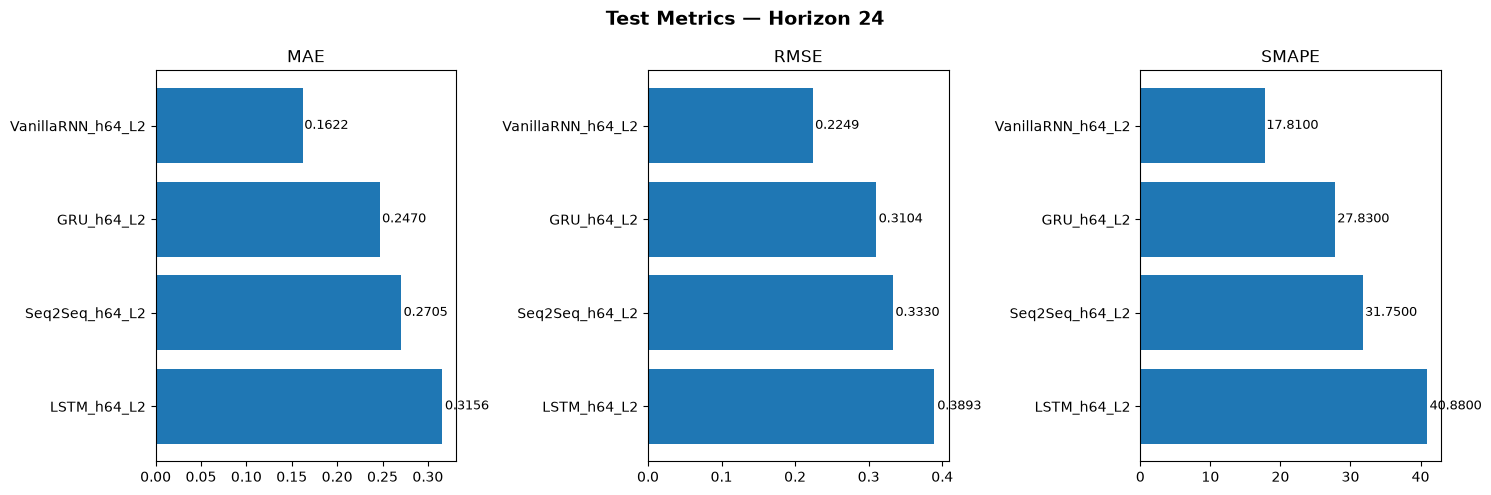

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ["mae", "rmse", "smape"]):
    values = results_df[metric]
    bars = ax.barh(values.index, values.values)
    ax.set_title(metric.upper())
    ax.invert_yaxis()
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.01 * val, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

plt.suptitle(f"Test Metrics — Horizon {FORECAST_HORIZON}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()